# Modeling

Try different models to predict average load

In [44]:
import pandas as pd

from sklearn.preprocessing import StandardScaler, OrdinalEncoder

def feature_engineered_filepath(res: str) -> str:
    return f"../data/003_feature_engineered/{res}_power_load.parquet"

RESAMPLE_RESOLUTIONS = ["1min", "5min", "10min"]


In [75]:
VAL_DAYS  = 3
TEST_DAYS = 3
DROP_COLS = ["timestamp", "load"]

def split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # 1. SORT FIRST (important for time series!)
    df = df.sort_values("timestamp")

    # 2. SPLIT FIRST (CRITICAL FIX)
    max_date = df["timestamp"].max()
    test_start = max_date - pd.Timedelta(days=TEST_DAYS)
    val_start  = test_start - pd.Timedelta(days=VAL_DAYS)

    df_train = df[df["timestamp"] <= val_start].copy()
    df_val   = df[(df["timestamp"] > val_start) & (df["timestamp"] <= test_start)].copy()
    df_test  = df[df["timestamp"] > test_start].copy()

    # 3. DROP NaNs AFTER SPLIT
    df_train = df_train.dropna()
    df_val   = df_val.dropna()
    df_test  = df_test.dropna()

    # 5. SPLIT X / y
    X_train, y_train = df_train.drop(columns=DROP_COLS), df_train["load"]
    X_val, y_val     = df_val.drop(columns=DROP_COLS), df_val["load"]
    X_test, y_test   = df_test.drop(columns=DROP_COLS), df_test["load"]

    return X_train, y_train, X_val, y_val, X_test, y_test


import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(y_true: pd.Series, y_pred: np.ndarray, model: str) -> None:
    """Plot actual vs predicted load."""

    plt.figure(figsize=(12, 5))

    plt.plot(y_true.to_numpy(), label="Actual", linewidth=2)
    plt.plot(y_pred, label=f"Predicted ({model})", linewidth=2, alpha=0.8)

    plt.title("Actual vs Predicted Load")
    plt.xlabel("Time Step")
    plt.ylabel("Load")
    plt.legend()
    plt.grid(True)

    plt.show()

def calculate_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    """Calculate evaluation metrics."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {"MAE": mae, "MSE": mse, "RMSE": rmse}

import numpy as np
import matplotlib.pyplot as plt

def plot_mae(y_true, y_preds, models):

    maes = []

    for y_pred in y_preds:
        metrics = calculate_metrics(y_true, y_pred)
        maes.append(metrics["MAE"])

    plt.figure(figsize=(6, 4))

    x = np.arange(len(models))

    plt.bar(x, maes, color="skyblue")

    plt.xticks(x, models, rotation=45)
    plt.title("MAE Comparison Across Models")
    plt.ylabel("MAE")
    plt.grid(axis="y")

    # value labels
    for i, v in enumerate(maes):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

In [64]:
df = pd.read_parquet(feature_engineered_filepath("1min"))
df["lag_1interval"] = df["load"].shift(1)
x_train, y_train, x_val, y_val, x_test, y_test = split(df)

In [89]:
df[["timestamp", "load", "lag_1interval"]].tail()

,timestamp,load,lag_1interval
44635,2025-12-28 23:55:00,1443.716667,1400.116667
44636,2025-12-28 23:56:00,1455.533333,1443.716667
44637,2025-12-28 23:57:00,1456.200000,1455.533333
44638,2025-12-28 23:58:00,1459.366667,1456.200000
44639,2025-12-28 23:59:00,1459.733333,1459.366667


### Baseline Model

Predictions = Yesterday's value

In [62]:
class BaselineModel:
    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return X["lag_1day"].bfill().values

baseline = BaselineModel()
baseline_preds = baseline.predict(x_val)

In [65]:
class PersistenceModel:
        
    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return X["lag_1interval"].values
    
baseline = PersistenceModel()
persistence_preds = baseline.predict(x_val)

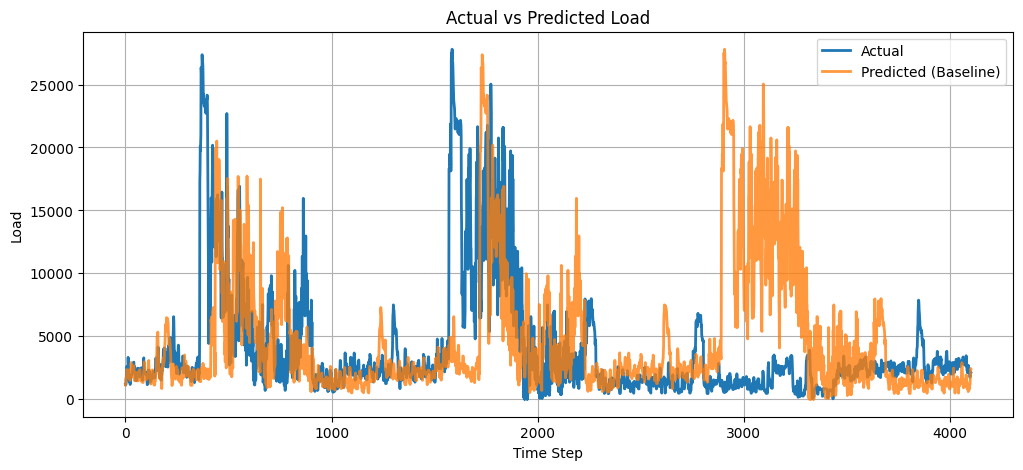

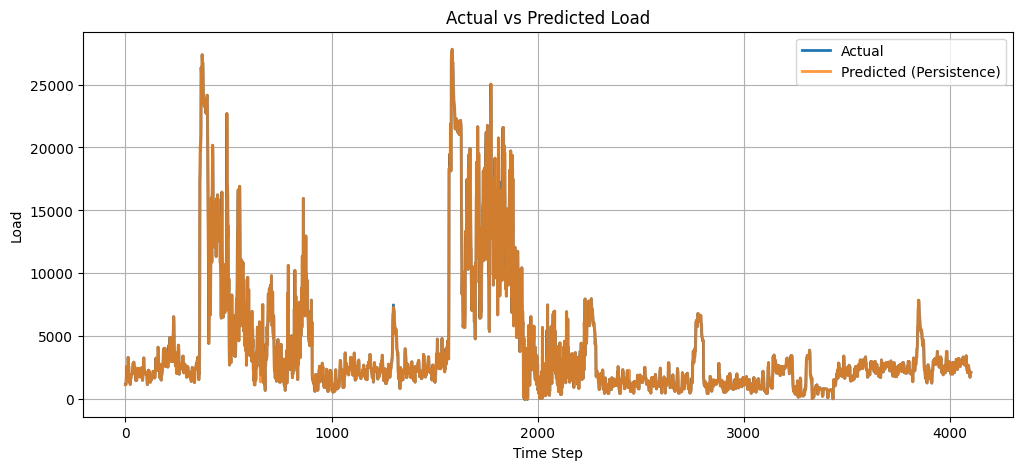

In [90]:
plot_predictions(y_val, baseline_preds, model="Baseline")
plot_predictions(y_val, persistence_preds, model="Persistence")

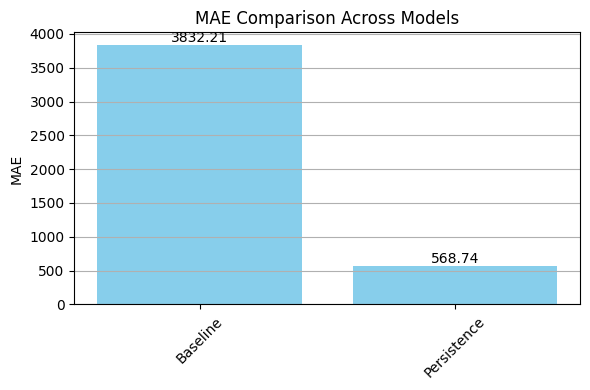

In [76]:
plot_mae(y_val, [baseline_preds, persistence_preds], models=["Baseline", "Persistence"])